In [1]:
import sys
from pathlib import Path

APP_DIR = Path.cwd().parent
sys.path.append(APP_DIR.as_posix())

In [2]:
# Chemins
OUTPUT_DIR = APP_DIR / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Imports graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Accessibilité : Daltonisme, Dyslexie, Confort Visuel
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

In [4]:
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from src.pipelines import MLPipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

c:\Users\Administrateur\Documents\M2i_CDSD_Projet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
ml_pipeline = MLPipeline()

train_dataset, validation_dataset, test_dataset = ml_pipeline._build_datasets()

print(f"Dimension jeu d'entrainement : {train_dataset.shape}")
print(f"Dimension jeu de validation : {validation_dataset.shape}")
print(f"Dimension jeu de test : {test_dataset.shape}")

Dimension jeu d'entrainement : (101152, 1326)
Dimension jeu de validation : (11072, 1326)
Dimension jeu de test : (13716, 1326)


In [6]:
def split_xy(
    dataset: pd.DataFrame,
    features: tuple[str],
) -> tuple[np.ndarray, np.ndarray]:
    feature_columns = [
        column for column in dataset.columns if column.startswith(features)
    ]

    target_columns = [
        column for column in dataset.columns if column.startswith("pitch")
    ]

    if not feature_columns:
        raise ValueError("No CQT feature columns found.")

    if not target_columns:
        raise ValueError("No piano-roll target columns found.")

    x = dataset[feature_columns].to_numpy(dtype=np.float32)
    y = dataset[target_columns].to_numpy(dtype=np.int32)

    return x, y


x_train, y_train = split_xy(train_dataset, ("cqt",))
x_validation, y_validation = split_xy(validation_dataset, ("cqt",))
x_test, y_test = split_xy(test_dataset, ("cqt",))

In [7]:
def build_model(
    input_dim: int,
    output_dim: int,
) -> tf.keras.Model:
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(input_dim,)),
            tf.keras.layers.Dense(512, activation="relu"),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(0.1),
            tf.keras.layers.Dense(output_dim, activation="sigmoid"),
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.F1Score(name="f1_weighted", average="weighted"),
        ],
    )

    return model


input_dim = x_train.shape[1]
output_dim = y_train.shape[1]
print("Input dimension: ", input_dim)
print("Output dimension: ", output_dim)

model = build_model(input_dim=input_dim, output_dim=output_dim)

Input dimension:  84
Output dimension:  64


In [8]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_validation = scaler.transform(x_validation)

In [9]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1,
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    batch_size=32,
    epochs=50,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

Epoch 1/50
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - f1_weighted: 0.4398 - loss: 0.0571 - precision: 0.7671 - recall: 0.5368 - val_f1_weighted: 0.5156 - val_loss: 0.0443 - val_precision: 0.8341 - val_recall: 0.6044 - learning_rate: 0.0010
Epoch 2/50
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - f1_weighted: 0.4776 - loss: 0.0422 - precision: 0.8272 - recall: 0.6674 - val_f1_weighted: 0.5157 - val_loss: 0.0432 - val_precision: 0.8273 - val_recall: 0.6204 - learning_rate: 0.0010
Epoch 3/50
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - f1_weighted: 0.4826 - loss: 0.0391 - precision: 0.8376 - recall: 0.6954 - val_f1_weighted: 0.5139 - val_loss: 0.0431 - val_precision: 0.8194 - val_recall: 0.6440 - learning_rate: 0.0010
Epoch 4/50
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - f1_weighted: 0.4854 - loss: 0.0372 - precision: 0.8443 - recall: 0.7123 - val_f1_weighted: 0.5145 - val_loss: 0.0435 - val_precision: 0.8153 - val_recall: 0.6538 - learning_rate: 0.0010
Epoch 5/50
3161/3161 ━━━━━━━━━━━

In [10]:
x_test = scaler.transform(x_test)

y_prob = model.predict(
    x_test,
    batch_size=256,
    verbose=0,
)

y_pred = (y_prob >= 0.3).astype(np.int32)

print(classification_report(y_test.ravel(), y_pred.ravel()))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    848480
           1       0.72      0.72      0.72     29344

    accuracy                           0.98    877824
   macro avg       0.85      0.86      0.85    877824
weighted avg       0.98      0.98      0.98    877824



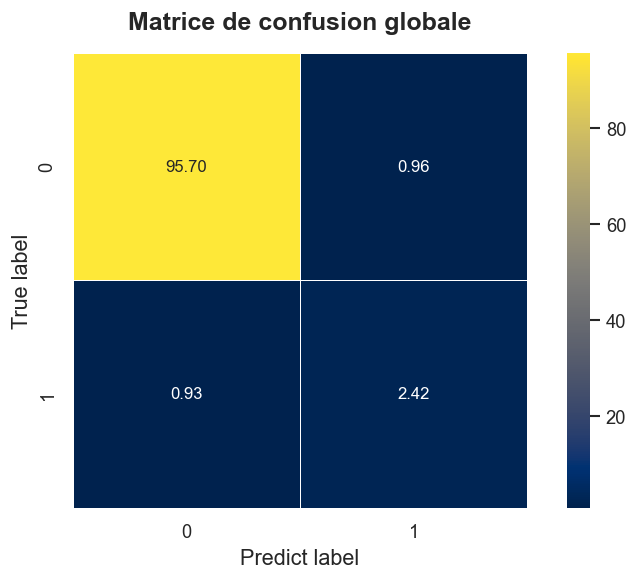

In [11]:
cm = confusion_matrix(
    y_test.ravel(),
    y_pred.ravel(),
)
cm_percent = cm / cm.sum().sum() * 100

fig, ax = plt.subplots(figsize=(7, 5))

heatmap = sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot_kws={"size": 10},
    ax=ax,
)
ax.set_title("Matrice de confusion globale", pad=14)
plt.xlabel("Predict label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

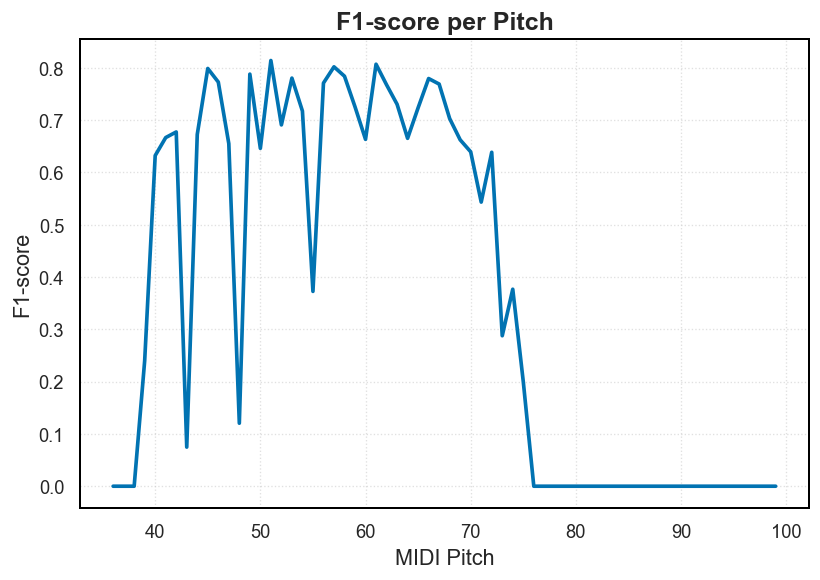

In [12]:
f1_scores = []

for k in range(y_test.shape[1]):
    score = f1_score(
        y_test[:, k],
        y_pred[:, k],
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    f1_scores.append(
        {
            "pitch_midi": k + 36,
            "f1_score": score,
        }
    )

df_scores = pd.DataFrame(f1_scores)

plt.figure(figsize=(7, 5))

plt.plot(
    df_scores["pitch_midi"],
    df_scores["f1_score"],
)
plt.title("F1-score per Pitch")
plt.xlabel("MIDI Pitch")
plt.ylabel("F1-score")

plt.tight_layout()
plt.show()

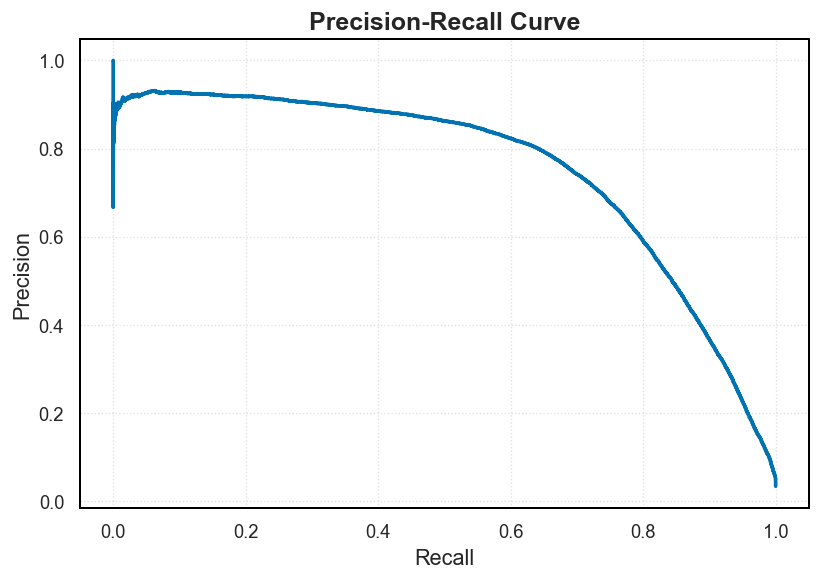

In [13]:
precision, recall, _ = precision_recall_curve(
    y_test.ravel(),
    y_prob.ravel(),
)

plt.figure(figsize=(7, 5))

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.tight_layout()
plt.show()

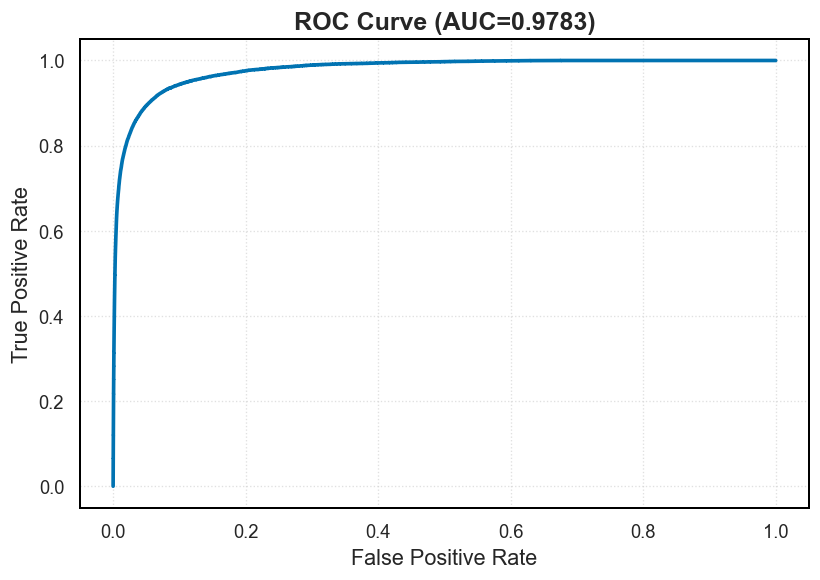

In [14]:
fpr, tpr, _ = roc_curve(
    y_test.ravel(),
    y_prob.ravel(),
)

auc_score = roc_auc_score(
    y_test,
    y_prob,
    average="micro",
)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC={auc_score:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.tight_layout()
plt.show()

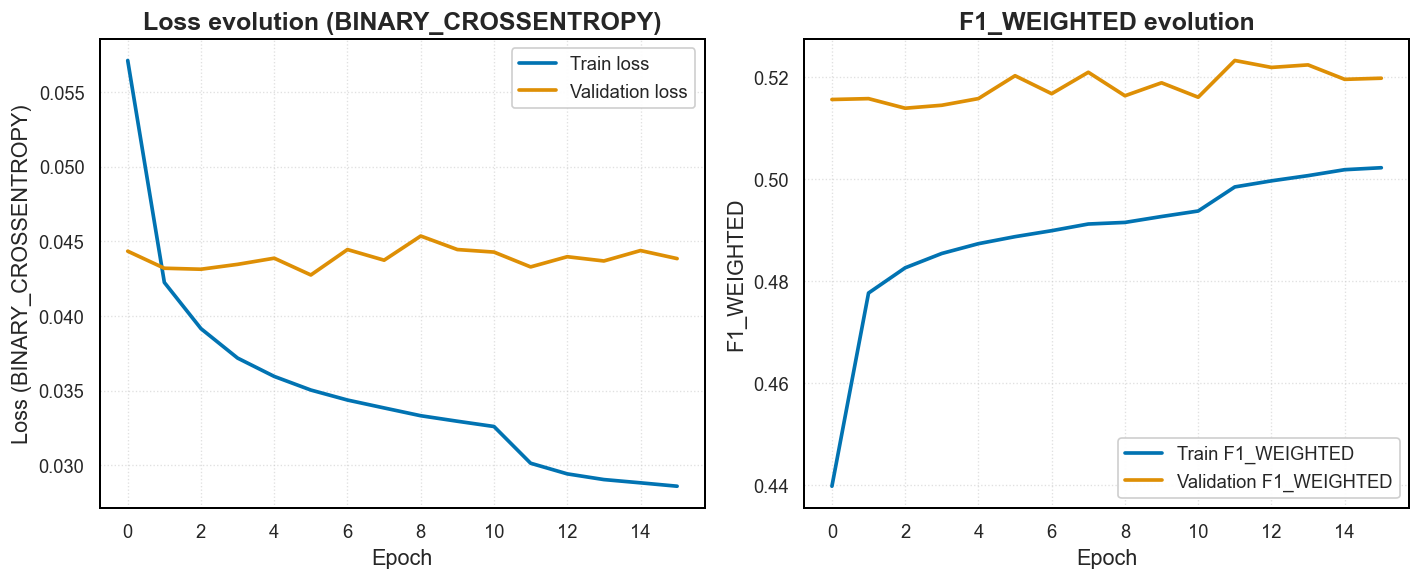

In [15]:
LOSS = "binary_crossentropy"
METRIC = "f1_weighted"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(history.history["loss"], label="Train loss")
ax1.plot(history.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel(f"Loss ({LOSS.upper()})")
ax1.set_title(f"Loss evolution ({LOSS.upper()})")
ax1.legend()

# Metric
ax2.plot(history.history[METRIC], label=f"Train {METRIC.upper()}")
ax2.plot(history.history[f"val_{METRIC}"], label=f"Validation {METRIC.upper()}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel(f"{METRIC.upper()}")
ax2.set_title(f"{METRIC.upper()} evolution")
ax2.legend()

plt.tight_layout()
plt.show()